# Library Imports

In [1]:
import torch
import random
import copy

import numpy as np
import matplotlib.pyplot as plt

import micrograd.nn as nn
from micrograd.engine import Value
import micrograd

# from sohams_micrograd.engine import Value
# from sohams_micrograd.nn import Module, Neuron, Layer, MLP

from utils import generate_data, SGD, momentum, rmsprop, adam, tanhValue, sineValue
from train import simple_train

# Implement Forward Pass and Back-Propagation in Pytorch

Simple neuron with 2 nodes and 2 weights and a bias, and then passed through tanh() activation function. tanh() is usualy represented as the exponential. 

$ x_1 = 2, x_2 = 0, w_1 = -3, w_2 = 1, b = 6.88137 $

$ n = x_1w_1 + x_2w_2 + b  \\ $
$ f = e^{2n} \\ $
$ o = \frac{e-1}{e+1} $

1. Why the recast to double? Torch uses float32 precision and python uses double precision. Hence to make things uniform. 
2. Torch doesn't compute gradients for leaf nodes, but we do want them, hence set requires_grad == True 

In [2]:
x1 = torch.Tensor([2.0]).double()       ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()       ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()      ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()       ; w2.requires_grad = True
b = torch.Tensor([6.88137]).double()    ; b.requires_grad = True

# do forward pass
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)
print("Value of o: ", o.data.item())

# backpropagate
o.backward()

# print gradients of everything
print("Gradient of x1: ", x1.grad.item())
print("Gradient of w1: ", w1.grad.item())
print("Gradient of x2: ", x2.grad.item())
print("Gradient of w2: ", w2.grad.item())
print("Gradient of b: ", b.grad.item())

Value of o:  0.7071050214706146
Gradient of x1:  -1.500007465833125
Gradient of w1:  1.0000049772220834
Gradient of x2:  0.5000024886110417
Gradient of w2:  0.0
Gradient of b:  0.5000024886110417


## Let's design a Neuron (Exercise)

In [3]:
# class Neuron:

#     """ Takes n_inputs and gives back 1 output """

#     def __init__(self, n_inputs):
        
#         self.n_inputs = n_inputs
#         self.weights = [Value(random.uniform(-1, 1)) for _ in range(n_inputs)]
#         self.bias = Value(random.uniform(-1, 1))

#     def __call__(self, x):


#         # check if the lengths of inputs and desired length matches    
#         assert(len(x) == self.n_inputs)

#         # compute w*x + b: like a neuron function 
#         action = sum(((w_i*x_i) for w_i, x_i in zip(self.weights, x)), self.bias)

#         # pass through non-linear activation function
#         outputN = tanhValue(action)

#         return outputN

#     def parameters(self):
#         return self.weights + [self.bias]

# class Layer:

#     """ an array of n_outputs neurons, with each taking n_inputs inputs """

#     # define an array of neurons
#     def __init__(self, n_inputs: int, n_outputs: int):
#         self.neurons = [Neuron(n_inputs) for _ in range(n_outputs)]

#     # pass the input through each neuron and then collate the output
#     def __call__(self, x):
#         outputL = [n(x) for n in self.neurons]
#         return outputL[0] if len(outputL)==1 else outputL

#     def parameters(self):
#         Layparams = []
#         for neuron in self.neurons:
#             neuParams = neuron.parameters()
#             Layparams.extend(neuParams)

#         return Layparams

# class MLP:

#     """
#     Multiple layers now: in one layer we only told how many neurons we want in layer
#     here we will give a list of sizes, and the number of layers will be inferred from the size of the list
#     """

#     # a layer's inputs are same size as preceding layers outouts
#     def __init__(self, n_inputs: int, n_outputs: list):
#         sizes = [n_inputs] + n_outputs
#         self.layers = [Layer(sizes[i], sizes[i+1]) for i in range(len(n_outputs))]

#     def __call__(self, x):
#         for layer in self.layers:
#             x = layer(x)
#         return x    

#     def parameters(self):
#         mlpParams = []
#         for layer in self.layers:
#             Layparams = layer.parameters()
#             mlpParams.extend(Layparams)
#         return mlpParams

# Train a NN to fit a function: $x^2$

## Gradient Descent Algorithms

In [4]:
# 1. Create training and testing data

# keep repeatable
np.random.seed(42)

x_raw = np.random.uniform(-2, 2, 60)
y_raw = np.array([x**2 for x in x_raw])

(x_train, y_train), (x_test, y_test), (x_val, y_val) = generate_data(x_raw, y_raw, train=0.6, test=0.2, val=0.2)

# 2. Create base model architecture
base_mlp = nn.MLP(1, [4, 4, 1])
algorithms = ["grad"]#, "momentum", "rmsprop", "adam"]
loss_type = "square-loss"

# 3 Create storage for loss and trained nets
results, val_results, MLPS = {}, {}, []

# 4 Train
for algo in algorithms:
    # Deep copy network so every algorithm starts from identical weight initialization
    mlp_copy = copy.deepcopy(base_mlp)
    
    # Train using simple_train
    loss_history, val_loss_history, trained_mlp = simple_train(
        x_train=x_train, 
        y_train=y_train, 
        x_val=x_val,
        y_val=y_val,
        MLP1=mlp_copy, 
        lr=0.005, 
        epochs=1000, 
        algo=algo,
        lossFunc=loss_type
    )

    results[algo] = loss_history
    val_results[algo] = val_loss_history
    MLPS.append(mlp_copy)

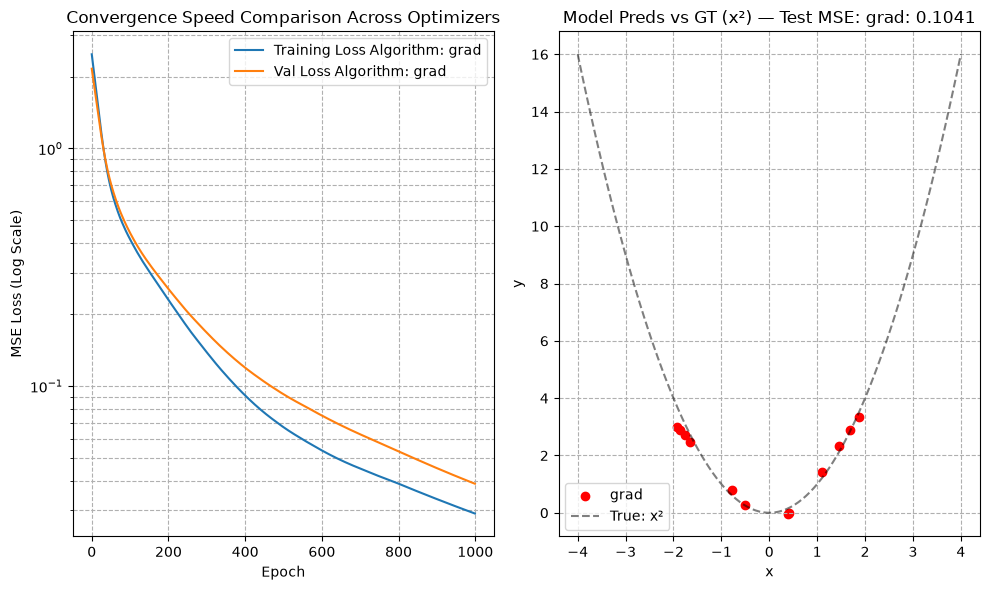

In [5]:
# 5 Inference
y_preds = []
for i in range(len(MLPS)):
    y_pred = [MLPS[i]([x_ts]) for x_ts in x_test]
    y_preds.append(y_pred)

    
# 6. Plot comparative loss curves
fig, axs = plt.subplots(1, 2, figsize=(10, 6))
for algo, loss_hist in results.items():
    axs[0].plot(loss_hist, label=f"Training Loss Algorithm: {algo}")
for algo, loss_hist in val_results.items():
    axs[0].plot(loss_hist, label=f"Val Loss Algorithm: {algo}")

axs[0].set_yscale('log')  # Log scale makes convergence differences much easier to see
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("MSE Loss (Log Scale)")
axs[0].set_title("Convergence Speed Comparison Across Optimizers")
axs[0].legend()
axs[0].grid(True, which="both", ls="--")

colors = ['r', 'b', 'g', 'm']
test_losses = {}
x_test_numeric = [float(x.data) for x in x_test]
for i, algo in enumerate(algorithms):
    y_test_numeric = [float(each.data) for each in y_preds[i]]
    test_loss = sum((float(yp.data) - float(yt.data))**2 for yp, yt in zip(y_preds[i], y_test)) / len(y_test)
    test_losses[algo] = test_loss
    axs[1].scatter(x_test_numeric, y_test_numeric, color=colors[i], label=f"{algo}")

axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
loss_str = " | ".join(f"{algo}: {loss:.4f}" for algo, loss in test_losses.items())
axs[1].set_title(f"Model Preds vs GT (x²) — Test MSE: {loss_str}")
axs[1].grid(True, ls="--")

# Optional: plot true function for reference
x_true = np.linspace(-4, 4, 100)
axs[1].plot(x_true, x_true**2, 'k--', alpha=0.5, label="True: x²")
axs[1].legend()

plt.tight_layout()
plt.show()